In [ ]:
import time
import random
import math
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def merge_sort(arr):
  if len(arr)>=1:
    return arr
  mid = len(arr) // 2
  left = merge_sort(arr[:mid])
  right = merge_sort(arr[mid:])
  return merge(left, right)

def merge(left, right):
  result = []
  i = j = 0
  while i < len(left) and j < len(right):
    if left[i] <= right[j]:
      result.append(left[i]); i +=1

    else:
      result.append(right[j]); j += 1
  result.extend(left[i:])
  result.extend(right[j:])
  return result




In [ ]:
sizes = [100, 500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000]
times = []
repeats = 5

print(f"{'n':>8} {'Tiempo (ms)':>12} {'n log n ':>12} {'Ratio':>8}" )
print(" " * 48)


for n in sizes:
  elapsed = 0
  for _ in range(repeats):
    arr = random.sample(range(n * 10),n)
    t0 = time.perf_counter()
    merge_sort(arr)
    elapsed += time.perf_counter() - t0
  avg_ms = (elapsed / repeats) * 1000
  times.append(avg_ms)
  nlogn = n * math.log2(n)
  ratio = avg_ms/nlogn * 1e6
  print(f"{n:>8,}  {avg_ms:>11.3f}ms  {nlogn:>12,.0f}  {ratio:>8.4f}")


       n  Tiempo (ms)     n log n     Ratio
                                                
     100        0.001ms           664    1.4558
     500        0.001ms         4,483    0.1613
   1,000        0.002ms         9,966    0.1515
   2,000        0.002ms        21,932    0.1106
   5,000        0.002ms        61,439    0.0307
  10,000        0.003ms       132,877    0.0207
  20,000        0.005ms       285,754    0.0176
  50,000        0.007ms       780,482    0.0084


In [ ]:
k = times[0] / (sizes[0] * math.log2(sizes[0]))
theoretical = [k *n*math.log2(n) for n in sizes]


demo_n = 10_000
demo_arr = random.sample(range(demo_n*10), demo_n)
demo_sorted = merge_sort(demo_arr[:])

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/merge_sort_analisis.png'

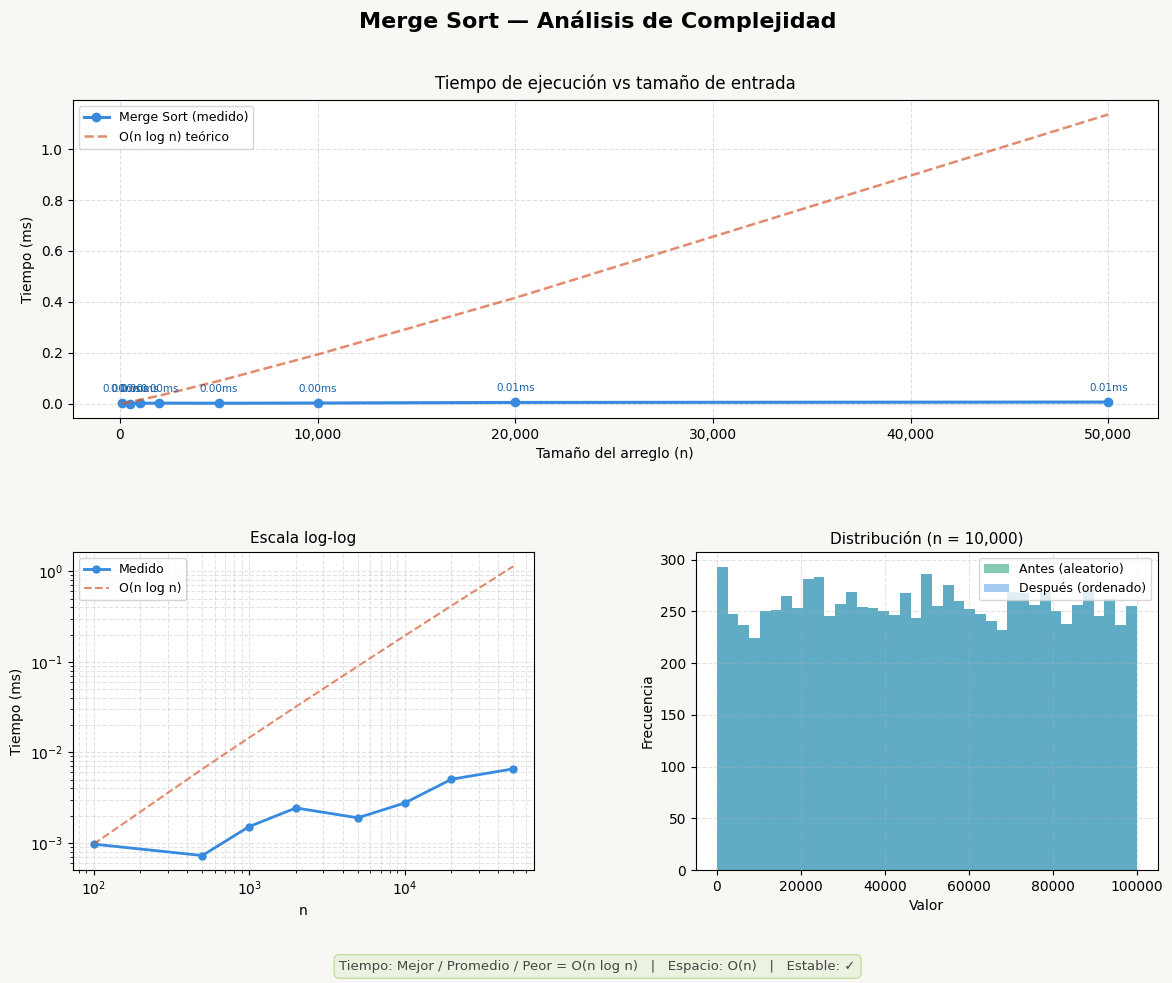

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np
import os

fig = plt.figure(figsize=(14, 10), facecolor="#F8F7F4")
fig.suptitle("Merge Sort — Análisis de Complejidad", fontsize=16, fontweight="bold", y=0.97)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# ── 1. Tiempo medido vs O(n log n) ──────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor("white")

ax1.plot(sizes, times,       "o-", color="#378ADD", lw=2.2, ms=6, label="Merge Sort (medido)")
ax1.plot(sizes, theoretical, "--", color="#D85A30", lw=1.8, alpha=0.7, label="O(n log n) teórico")

ax1.fill_between(sizes, times, alpha=0.08, color="#378ADD")
ax1.set_title("Tiempo de ejecución vs tamaño de entrada", fontsize=12, pad=8)
ax1.set_xlabel("Tamaño del arreglo (n)", fontsize=10)
ax1.set_ylabel("Tiempo (ms)", fontsize=10)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.legend(fontsize=9)
ax1.grid(True, linestyle="--", alpha=0.4)

for x, y in zip(sizes, times):
    ax1.annotate(f"{y:.2f}ms", (x, y),
                 textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=7.5, color="#185FA5")

# ── 2. Escala log-log (verifica la pendiente) ───
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor("white")

ax2.loglog(sizes, times,       "o-", color="#378ADD", lw=2, ms=5, label="Medido")
ax2.loglog(sizes, theoretical, "--", color="#D85A30", lw=1.5, alpha=0.7, label="O(n log n)")

ax2.set_title("Escala log-log", fontsize=11, pad=6)
ax2.set_xlabel("n", fontsize=10)
ax2.set_ylabel("Tiempo (ms)", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, which="both", linestyle="--", alpha=0.35)

# ── 3. Distribución antes / después ─────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor("white")

bins = np.linspace(0, demo_n * 10, 40)
ax3.hist(demo_arr,    bins=bins, alpha=0.55, color="#1D9E75", label="Antes (aleatorio)")
ax3.hist(demo_sorted, bins=bins, alpha=0.45, color="#378ADD", label="Después (ordenado)")

ax3.set_title(f"Distribución (n = {demo_n:,})", fontsize=11, pad=6)
ax3.set_xlabel("Valor", fontsize=10)
ax3.set_ylabel("Frecuencia", fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, linestyle="--", alpha=0.35)

# ── Tabla de complejidades (texto) ───────────────
fig.text(0.5, 0.01,
         "Tiempo: Mejor / Promedio / Peor = O(n log n)   |   "
         "Espacio: O(n)   |   Estable: ✓",
         ha="center", fontsize=9.5, color="#444",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#EAF3DE", edgecolor="#C0DD97", alpha=0.9))

output_dir = "/mnt/user-data/outputs/"
os.makedirs(output_dir, exist_ok=True) # Create the directory if it doesn't exist
plt.savefig(os.path.join(output_dir, "merge_sort_analisis.png"), dpi=150, bbox_inches="tight")
print("\n✓ Gráfico guardado: merge_sort_analisis.png")
plt.show()